# Импорты

In [ ]:
!git clone https://github.com/evagogua/denoiseML

Cloning into 'denoiseML'...
remote: Enumerating objects: 104, done.
remote: Counting objects: 100% (104/104), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 104 (delta 30), reused 45 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (104/104), 6.01 MiB | 4.22 MiB/s, done.
Resolving deltas: 100% (30/30), done.


In [ ]:
!pip install -r "/content/denoiseML/requirements.txt"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.0/110.0 kB 7.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.9/314.9 kB 5.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 140.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 117.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 100.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 8.0 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely n

In [ ]:
import sys
import os

repo_name = "denoiseML"
os.chdir(f'/content/{repo_name}')

from src.models.denoise_model import (
    DenoiseDataset,
    make_last_subtoken_mask,
    prepare_denoise_dataset_from_json
)
from src.inference.denoiser import (
    denoising,
    predict_with_trainer,
    evaluate_on_test_set,
    test
)
from src.models.trainer import (
    plot_training_curves,
    compute_metrics,
    final_report
)

# Обучение

In [ ]:
from transformers import AutoTokenizer, AutoModelForMaskedLM, AutoModelForTokenClassification

google_tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-multilingual-uncased")
google_model = AutoModelForTokenClassification.from_pretrained("google-bert/bert-base-multilingual-uncased")

model.safetensors:   0%|          | 0.00/672M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: google-bert/bert-base-multilingual-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params 

### banking+credit_cards

In [ ]:
train_banking_credit_noise_dataset, test_banking_credit_noise_dataset = prepare_denoise_dataset_from_json('/content/denoiseML/data/noise_data_banking_credit.json', tokenizer=google_tokenizer, test_size=0.2, seed=42, verbose=True)

Пример из train (исходные данные):
{'text': ['на', 'что', 'татумастер', 'годятся', 'мя', 'мои', 'несчаст', 'шедевры', 'понятно'], 'denoise_labels': ['0', '0', 'N', '0', 'N', '0', 'N', '0', 'N'], 'classification_labels': 'redeem_rewards'}

Пример из train (после токенизации):
{'input_ids': [101, 10124, 10887, 10556, 12920, 11065, 27340, 12191, 43642, 318, 10401, 55566, 10396, 10580, 89720, 10386, 330, 75443, 57267, 10328, 10291, 54474, 10758, 102], 'mask': [False, True, True, False, False, False, True, False, True, False, True, True, False, False, False, True, False, False, False, True, False, False, True, False], 'labels': array([-100,    0,    0, -100, -100, -100,    1, -100,    0, -100,    1,
          0, -100, -100, -100,    1, -100, -100, -100,    0, -100, -100,
          1, -100])}



In [ ]:
from transformers import AutoModelForSequenceClassification, AutoModelForTokenClassification
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer, DataCollatorForTokenClassification
# from transformers.optimization import AdamW
from torch.optim import AdamW, Adam
import numpy as np

banking_credit_denoise_google_model = AutoModelForTokenClassification.from_pretrained("google-bert/bert-base-multilingual-uncased", num_labels=len(train_banking_credit_noise_dataset.tags_))
optimizer = AdamW(banking_credit_denoise_google_model.parameters(), lr=1e-4, weight_decay=0.1)
training_args = TrainingArguments(
                  output_dir="trainer_logs", eval_strategy="steps", save_strategy='steps',
                  logging_strategy="steps", logging_steps=50, save_total_limit=2,
                  num_train_epochs=1, eval_steps=50, disable_tqdm=False,
                  metric_for_best_model='Accuracy',
                  warmup_ratio=0.1,
                  report_to="none"
              )
banking_credit_denoise_google_trainer = Trainer(
    model=banking_credit_denoise_google_model,
    optimizers=(optimizer, None),
    args=training_args,
    data_collator=DataCollatorForTokenClassification(tokenizer=google_tokenizer),
    train_dataset=train_banking_credit_noise_dataset,
    eval_dataset=test_banking_credit_noise_dataset,
    compute_metrics=compute_metrics)
banking_credit_denoise_google_trainer.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: google-bert/bert-base-multilingual-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params 

Step,Training Loss,Validation Loss,Accuracy,Precision 0,Recall 0,F1 0,Precision N,Recall N,F1 N,Macro Precision,Macro Recall,Macro F1
50,0.480840,0.409761,83.146248,98.011720,70.000000,81.670736,73.914739,98.356970,84.401900,85.963230,84.178485,83.036318
100,0.259151,0.205785,92.118345,93.731801,91.420030,92.561483,90.348075,92.926323,91.619064,92.039938,92.173176,92.090274
150,0.198814,0.211315,92.743746,94.575435,91.733931,93.133015,90.757145,93.912141,92.307692,92.666290,92.823036,92.720353
200,0.200395,0.177327,93.617704,93.672199,94.484305,94.076499,93.553459,92.615012,93.081870,93.612829,93.549659,93.579185
250,0.170114,0.146056,94.475625,95.984674,93.617339,94.786228,92.819909,95.468696,94.125671,94.402292,94.543018,94.455950
300,0.141350,0.136300,94.956703,95.036410,95.590433,95.312616,94.863312,94.223452,94.542299,94.949861,94.906943,94.927458
350,0.141880,0.124849,95.469852,96.691569,94.798206,95.735527,94.114663,96.246973,95.168876,95.403116,95.522590,95.452201
400,0.118015,0.118019,95.750481,96.066407,96.008969,96.037679,95.385413,95.451401,95.418396,95.725910,95.730185,95.728037


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=420, training_loss=0.20982827913193475, metrics={'train_runtime': 122.2144, 'train_samples_per_second': 27.493, 'train_steps_per_second': 3.437, 'total_flos': 91911134181888.0, 'train_loss': 0.20982827913193475, 'epoch': 1.0})

In [ ]:
final_report(banking_credit_denoise_google_trainer, test_banking_credit_noise_dataset)

              precision    recall  f1-score   support

Целевая речь       0.96      0.96      0.96      6690
         Шум       0.95      0.95      0.95      5782

    accuracy                           0.96     12472
   macro avg       0.96      0.96      0.96     12472
weighted avg       0.96      0.96      0.96     12472



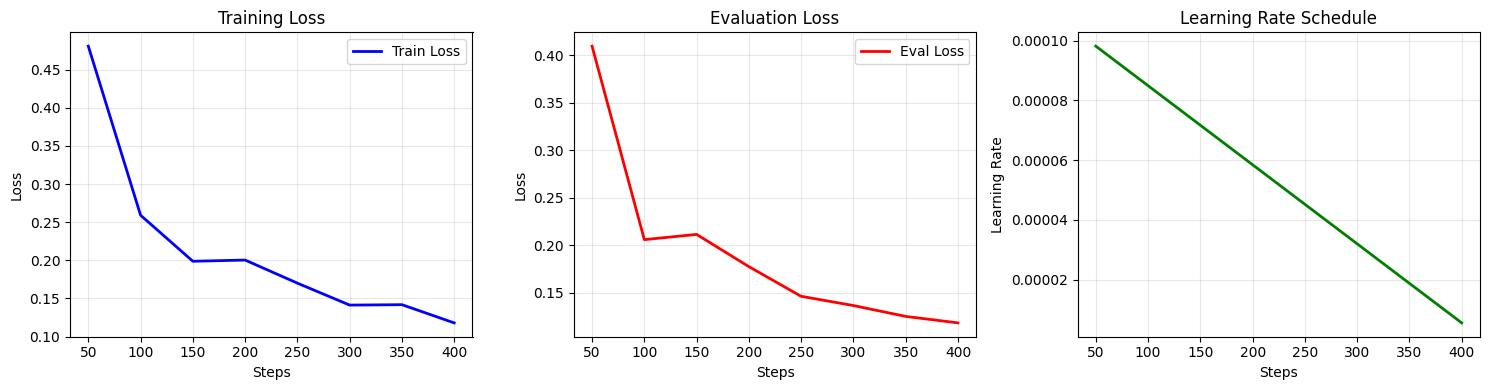

In [ ]:
plot_training_curves(banking_credit_denoise_google_trainer)

In [ ]:
evaluate_on_test_set(
    trainer=banking_credit_denoise_google_trainer,
    tokenizer=google_tokenizer,
    test_samples=test,
)

переведите деньги на мой счет
0 0 0 0 0
0 0 0 0 0
5/5
алиса какой канал переведите сто долларов на сберкнижку
0 0 0 0 0 0 0 0
N N N 0 0 0 0 0
5/8
выключи телевизор заблокируй карту срочно пожалуйста
0 N 0 0 N 0
N N 0 0 0 0
4/6
привет как дела что делаешь переведи пять тысяч на вклад
0 0 0 0 N 0 0 0 0 0
N N N N N 0 0 0 0 0
6/10
ну я ему говорю а он такой слушай переведите пожалуйста средства
0 0 N N N N N N 0 0 0
N N N N N N N N 0 0 0
9/11
какой баланс моей карты
0 0 0 0
0 0 0 0
4/4
погода сегодня алиса какой баланс на карте
0 0 N 0 0 0 0
N N N 0 0 0 0
5/7
переведи деньги срочно сделай тише я сказал
0 0 0 0 N 0 0
0 0 0 N N N N
4/7
перевод средств на карту сбербанка
0 0 0 0 0
0 0 0 0 0
5/5
иди сюда быстрее посмотри что я нашел переведи сто баксов
0 0 0 0 0 0 0 N N 0
N N N N N N N 0 0 0
1/10

ОСНОВНЫЕ МЕТРИКИ
Token Accuracy:    65.75%

КЛАСС 0 (ЦЕЛЕВАЯ РЕЧЬ):
  Precision: 63.33%
  Recall:    92.68%
  F1:        75.25%

КЛАСС N (ШУМ):
  Precision: 76.92%
  Recall:    31.25%
  F1:        44

In [ ]:
model_save_path = "banking_credit_denoise_google_model"
banking_credit_denoise_google_trainer.save_model(model_save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### all_labels

In [ ]:
train_full_noise_dataset, test_full_noise_dataset = prepare_denoise_dataset_from_json('/content/denoiseML/data/noise_data_all.json', tokenizer=google_tokenizer, test_size=0.2, seed=42, verbose=True)

Generating train split: 0 examples [00:00, ? examples/s]

Пример из train (исходные данные):
{'text': ['мне', 'нужна', 'сигнализация', 'чтобы', 'разбудить', 'меня', 'завтра', 'в', 'финес', 'и', 'ферб', '8', 'а', 'ты', 'откуда', 'утра'], 'denoise_labels': ['0', '0', '0', '0', '0', '0', '0', '0', 'N', 'N', 'N', '0', 'N', 'N', 'N', '0'], 'classification_labels': 'alarm'}

Пример из train (после токенизации):
{'input_ids': [101, 53571, 319, 10236, 24578, 77667, 79725, 15561, 17552, 19647, 63029, 51892, 10242, 40983, 11136, 309, 326, 18345, 10580, 315, 326, 12576, 12063, 129, 307, 52195, 88413, 325, 26667, 102], 'mask': [False, True, False, False, True, False, True, True, False, False, True, True, False, False, True, True, False, False, True, True, False, False, True, True, True, True, True, False, True, False], 'labels': array([-100,    0, -100, -100,    0, -100,    0,    0, -100, -100,    0,
          0, -100, -100,    0,    0, -100, -100,    1,    1, -100, -100,
          1,    0,    1,    1,    1, -100,    0, -100])}



In [ ]:
from transformers import AutoModelForSequenceClassification, AutoModelForTokenClassification
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer, DataCollatorForTokenClassification
# from transformers.optimization import AdamW
from torch.optim import AdamW, Adam
import numpy as np

full_denoise_google_model = AutoModelForTokenClassification.from_pretrained("google-bert/bert-base-multilingual-uncased", num_labels=len(train_full_noise_dataset.tags_))
optimizer = AdamW(full_denoise_google_model.parameters(), lr=1e-4, weight_decay=0.1)
training_args = TrainingArguments(
                  output_dir="trainer_logs", eval_strategy="steps", save_strategy='steps',
                  logging_strategy="steps", logging_steps=50, save_total_limit=2,
                  num_train_epochs=1, eval_steps=50, disable_tqdm=False,
                  metric_for_best_model='Accuracy',
                  warmup_ratio=0.1,
                  report_to="none"
              )
full_denoise_google_trainer = Trainer(
    model=full_denoise_google_model,
    optimizers=(optimizer, None),
    args=training_args,
    data_collator=DataCollatorForTokenClassification(tokenizer=google_tokenizer),
    train_dataset=train_full_noise_dataset,
    eval_dataset=test_full_noise_dataset,
    compute_metrics=compute_metrics)
full_denoise_google_trainer.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: google-bert/bert-base-multilingual-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params 

Step,Training Loss,Validation Loss,Accuracy,Precision 0,Recall 0,F1 0,Precision N,Recall N,F1 N,Macro Precision,Macro Recall,Macro F1
50,0.600690,0.451241,78.533515,77.928563,79.636238,78.773147,79.165999,77.430066,78.288411,78.547281,78.533152,78.530779
100,0.410939,0.359404,85.025130,87.065253,82.284623,84.607461,83.196247,87.767440,85.420732,85.130750,85.026032,85.014097
150,0.356349,0.388089,82.950507,77.497715,92.881292,84.495009,91.110937,73.013188,81.064255,84.304326,82.947240,82.779632
200,0.358795,0.314351,86.277733,85.778231,86.986602,86.378190,86.791853,85.568399,86.175784,86.285042,86.277500,86.276987
250,0.336262,0.280616,88.587220,91.639926,84.929877,88.157403,85.949448,92.246969,88.986931,88.794687,88.588423,88.572167
300,0.323031,0.269165,88.731270,88.758027,88.705234,88.731623,88.704527,88.757322,88.730917,88.731277,88.731278,88.731270
350,0.301713,0.280888,89.135234,91.953290,85.784498,88.761843,86.669994,92.488175,89.484611,89.311642,89.136336,89.123227
400,0.268471,0.267775,89.382623,88.483773,90.558477,89.509105,90.325271,88.205996,89.253055,89.404522,89.382237,89.381080
450,0.266605,0.284792,89.164983,87.414030,91.513273,89.416695,91.089565,86.815149,88.901007,89.251797,89.164211,89.158851
500,0.248333,0.269501,89.385755,93.036221,85.152141,88.919763,86.303783,93.622153,89.814133,89.670002,89.387147,89.366948


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2370, training_loss=0.2136601881638861, metrics={'train_runtime': 1538.8564, 'train_samples_per_second': 12.321, 'train_steps_per_second': 1.54, 'total_flos': 488788245569280.0, 'train_loss': 0.2136601881638861, 'epoch': 1.0})

In [ ]:
final_report(full_denoise_google_trainer, test_full_noise_dataset)

              precision    recall  f1-score   support

Целевая речь       0.95      0.96      0.96     31944
         Шум       0.96      0.95      0.96     31923

    accuracy                           0.96     63867
   macro avg       0.96      0.96      0.96     63867
weighted avg       0.96      0.96      0.96     63867



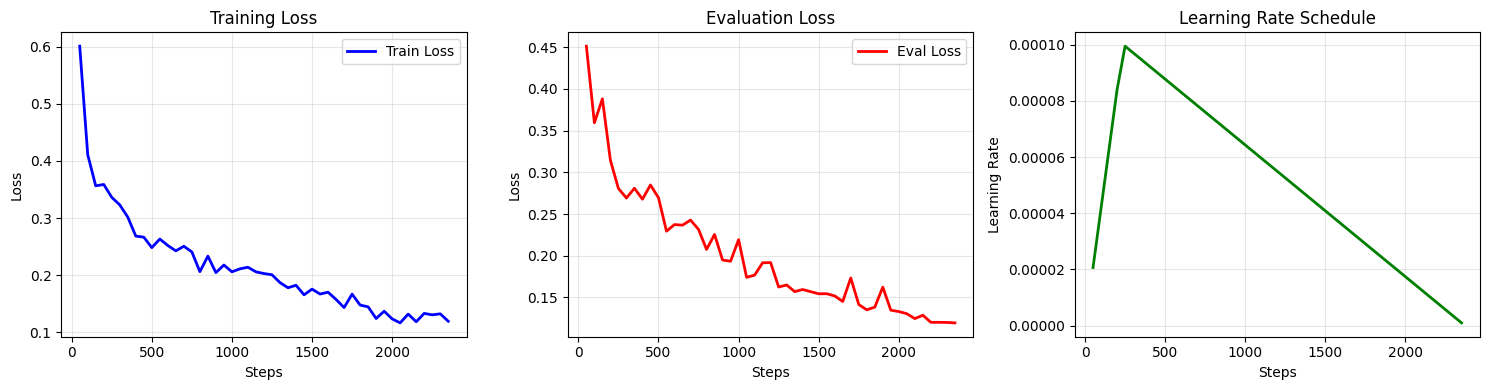

In [ ]:
plot_training_curves(full_denoise_google_trainer)

In [ ]:
evaluate_on_test_set(
    trainer=full_denoise_google_trainer,
    tokenizer=google_tokenizer,
    test_samples=test,
)

переведите деньги на мой счет
0 0 0 0 0
0 0 0 0 0
5/5
алиса какой канал переведите сто долларов на сберкнижку
0 0 0 0 0 0 0 0
N N N 0 0 0 0 0
5/8
выключи телевизор заблокируй карту срочно пожалуйста
0 0 0 0 N 0
N N 0 0 0 0
3/6
привет как дела что делаешь переведи пять тысяч на вклад
0 0 0 N N 0 0 0 0 0
N N N N N 0 0 0 0 0
7/10
ну я ему говорю а он такой слушай переведите пожалуйста средства
0 0 0 0 N N N N 0 0 0
N N N N N N N N 0 0 0
7/11
какой баланс моей карты
0 0 0 0
0 0 0 0
4/4
погода сегодня алиса какой баланс на карте
0 0 0 N N N N
N N N 0 0 0 0
0/7
переведи деньги срочно сделай тише я сказал
0 0 N 0 N N N
0 0 0 N N N N
5/7
перевод средств на карту сбербанка
0 0 0 0 0
0 0 0 0 0
5/5
иди сюда быстрее посмотри что я нашел переведи сто баксов
0 0 0 N 0 0 N N 0 0
N N N N N N N 0 0 0
4/10

ОСНОВНЫЕ МЕТРИКИ
Token Accuracy:    61.64%

КЛАСС 0 (ЦЕЛЕВАЯ РЕЧЬ):
  Precision: 61.82%
  Recall:    82.93%
  F1:        70.83%

КЛАСС N (ШУМ):
  Precision: 61.11%
  Recall:    34.38%
  F1:        44

In [ ]:
model_save_path = "full_denoise_google_model"
full_denoise_google_trainer.save_model(model_save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### bctw_labels

In [ ]:
train_bctw_noise_dataset, test_bctw_noise_dataset = prepare_denoise_dataset_from_json('/content/denoiseML/data/noise_data_bctw.json', tokenizer=google_tokenizer, test_size=0.2, seed=42, verbose=True)

Generating train split: 0 examples [00:00, ? examples/s]

Пример из train (исходные данные):
{'text': ['сколько', 'я', 'должен', 'заплатить', 'ась', 'где', 'в', 'та', 'надоели', 'этом', 'месяце'], 'denoise_labels': ['0', '0', '0', '0', 'N', 'N', '0', 'N', 'N', '0', '0'], 'classification_labels': 'bill_balance'}

Пример из train (после токенизации):
{'input_ids': [101, 323, 91668, 337, 33403, 10242, 11027, 56925, 11569, 87560, 10979, 12472, 309, 10556, 12779, 17494, 10798, 14907, 73233, 10226, 102], 'mask': [False, False, True, True, True, False, False, False, True, False, True, True, True, True, False, False, True, True, False, True, False], 'labels': array([-100, -100,    0,    0,    0, -100, -100, -100,    0, -100,    1,
          1,    0,    1, -100, -100,    1,    0, -100,    0, -100])}



In [ ]:
from transformers import AutoModelForSequenceClassification, AutoModelForTokenClassification
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer, DataCollatorForTokenClassification
# from transformers.optimization import AdamW
from torch.optim import AdamW, Adam
import numpy as np

bctw_denoise_google_model = AutoModelForTokenClassification.from_pretrained("google-bert/bert-base-multilingual-uncased", num_labels=len(train_bctw_noise_dataset.tags_))
optimizer = AdamW(bctw_denoise_google_model.parameters(), lr=1e-4, weight_decay=0.1)
training_args = TrainingArguments(
                  output_dir="trainer_logs", eval_strategy="steps", save_strategy='steps',
                  logging_strategy="steps", logging_steps=50, save_total_limit=2,
                  num_train_epochs=1, eval_steps=50, disable_tqdm=False,
                  metric_for_best_model='Accuracy',
                  warmup_ratio=0.1,
                  report_to="none"
              )
bctw_denoise_google_trainer = Trainer(
    model=bctw_denoise_google_model,
    optimizers=(optimizer, None),
    args=training_args,
    data_collator=DataCollatorForTokenClassification(tokenizer=google_tokenizer),
    train_dataset=train_bctw_noise_dataset,
    eval_dataset=test_bctw_noise_dataset,
    compute_metrics=compute_metrics)
bctw_denoise_google_trainer.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: google-bert/bert-base-multilingual-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params 

Step,Training Loss,Validation Loss,Accuracy,Precision 0,Recall 0,F1 0,Precision N,Recall N,F1 N,Macro Precision,Macro Recall,Macro F1
50,0.532659,0.347321,85.140224,83.135696,89.771507,86.326267,87.735589,80.072160,83.728888,85.435642,84.921834,85.027578
100,0.295007,0.281720,88.958333,87.219569,92.409140,89.739389,91.114701,85.182078,88.048569,89.167135,88.795609,88.893979
150,0.279819,0.272364,90.528846,87.811615,95.069775,91.296664,94.068266,85.559658,89.612444,90.939940,90.314716,90.454554
200,0.227416,0.231668,91.634615,89.763322,94.801411,92.213604,93.938852,88.169156,90.962604,91.851087,91.485283,91.588104
250,0.213167,0.197821,92.684295,95.787067,89.955528,92.779755,89.694777,95.670414,92.586277,92.740922,92.812971,92.683016
300,0.204871,0.185091,92.900641,96.052632,90.116547,92.989952,89.869538,95.947307,92.809025,92.961085,93.031927,92.899488
350,0.179540,0.180335,93.361378,92.057628,95.537494,93.765286,94.905908,90.980030,92.901512,93.481768,93.258762,93.333399
400,0.191735,0.157701,93.926282,93.389550,95.108112,94.240997,94.536736,92.632992,93.575182,93.963143,93.870552,93.908090
450,0.173692,0.154655,94.238782,93.111904,96.081889,94.573585,95.557294,92.221849,93.859949,94.334599,94.151869,94.216767
500,0.162324,0.142501,94.743590,96.341656,93.490262,94.894544,93.099805,96.115120,94.583437,94.720731,94.802691,94.738990


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=825, training_loss=0.19914495265845097, metrics={'train_runtime': 427.7305, 'train_samples_per_second': 15.43, 'train_steps_per_second': 1.929, 'total_flos': 178702485036480.0, 'train_loss': 0.19914495265845097, 'epoch': 1.0})

In [ ]:
final_report(bctw_denoise_google_trainer, test_bctw_noise_dataset)

              precision    recall  f1-score   support

Целевая речь       0.97      0.96      0.96     13042
         Шум       0.95      0.96      0.96     11918

    accuracy                           0.96     24960
   macro avg       0.96      0.96      0.96     24960
weighted avg       0.96      0.96      0.96     24960



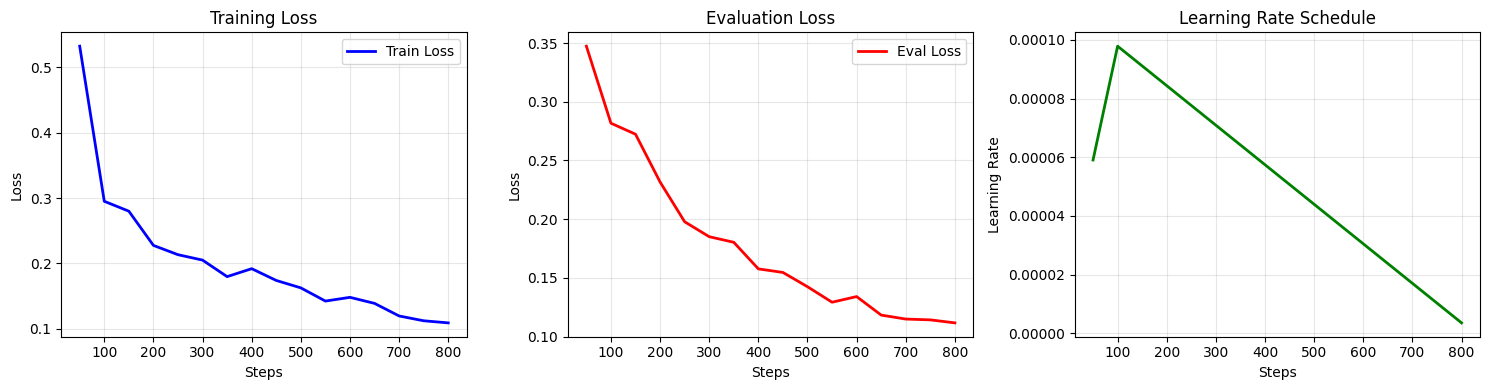

In [ ]:
plot_training_curves(bctw_denoise_google_trainer)

In [ ]:
evaluate_on_test_set(
    trainer=bctw_denoise_google_trainer,
    tokenizer=google_tokenizer,
    test_samples=test,
)

переведите деньги на мой счет
0 0 0 0 0
0 0 0 0 0
5/5
алиса какой канал переведите сто долларов на сберкнижку
0 0 0 0 0 0 0 0
N N N 0 0 0 0 0
5/8
выключи телевизор заблокируй карту срочно пожалуйста
N N 0 0 N 0
N N 0 0 0 0
5/6
привет как дела что делаешь переведи пять тысяч на вклад
0 0 0 N N 0 0 0 0 0
N N N N N 0 0 0 0 0
7/10
ну я ему говорю а он такой слушай переведите пожалуйста средства
0 N N N N N N N 0 0 0
N N N N N N N N 0 0 0
10/11
какой баланс моей карты
0 0 0 0
0 0 0 0
4/4
погода сегодня алиса какой баланс на карте
0 0 N 0 0 0 0
N N N 0 0 0 0
5/7
переведи деньги срочно сделай тише я сказал
0 0 N N N 0 0
0 0 0 N N N N
4/7
перевод средств на карту сбербанка
0 0 0 0 0
0 0 0 0 0
5/5
иди сюда быстрее посмотри что я нашел переведи сто баксов
0 0 0 N 0 0 0 N 0 0
N N N N N N N 0 0 0
3/10

ОСНОВНЫЕ МЕТРИКИ
Token Accuracy:    72.60%

КЛАСС 0 (ЦЕЛЕВАЯ РЕЧЬ):
  Precision: 69.09%
  Recall:    92.68%
  F1:        79.17%

КЛАСС N (ШУМ):
  Precision: 83.33%
  Recall:    46.88%
  F1:        6

In [ ]:
model_save_path = "bctw_denoise_google_model"
bctw_denoise_google_trainer.save_model(model_save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]